# Real-Domain SimSiam

Implementation of the real-domain self-supervised learning branch used in the prismPYP reproduction.

The notebook first verifies the SimSiam architecture and forward pass before moving to GPU-based training.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
from pathlib import Path

import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms

In [2]:
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
Device: cpu


## 2. Load Micrograph

In [3]:
data_dir = Path("../data/raw/empiar_10379")
mrc_files = sorted(data_dir.glob("*.mrc"))

mrc_path = mrc_files[0]

with mrcfile.open(mrc_path, permissive=True) as mrc:
    micrograph = np.array(mrc.data)

print("File:", mrc_path.name)
print("Shape:", micrograph.shape)

File: 18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
Shape: (3710, 3838)


## 3. Prepare Model Input

The ResNet-50 encoder expects a fixed spatial input size. For the initial implementation, the micrograph is converted to a 224 × 224 tensor.

In [4]:
micrograph_norm = (
    micrograph - micrograph.min()
) / (
    micrograph.max() - micrograph.min()
)

print(
    "Normalized range:",
    micrograph_norm.min(),
    micrograph_norm.max()
)

Normalized range: 0.0 1.0


In [5]:
from PIL import Image

image = Image.fromarray(
    (micrograph_norm * 255).astype(np.uint8)
)

image.size

(3838, 3710)

## 4. Real-Domain Augmentation

SimSiam learns from two augmented views of the same image. The augmentations should change the appearance of the input while preserving the underlying image content.

In [6]:
real_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
])

In [7]:
view1 = real_transform(image)
view2 = real_transform(image)

print("View 1:", view1.shape)
print("View 2:", view2.shape)

View 1: torch.Size([1, 224, 224])
View 2: torch.Size([1, 224, 224])


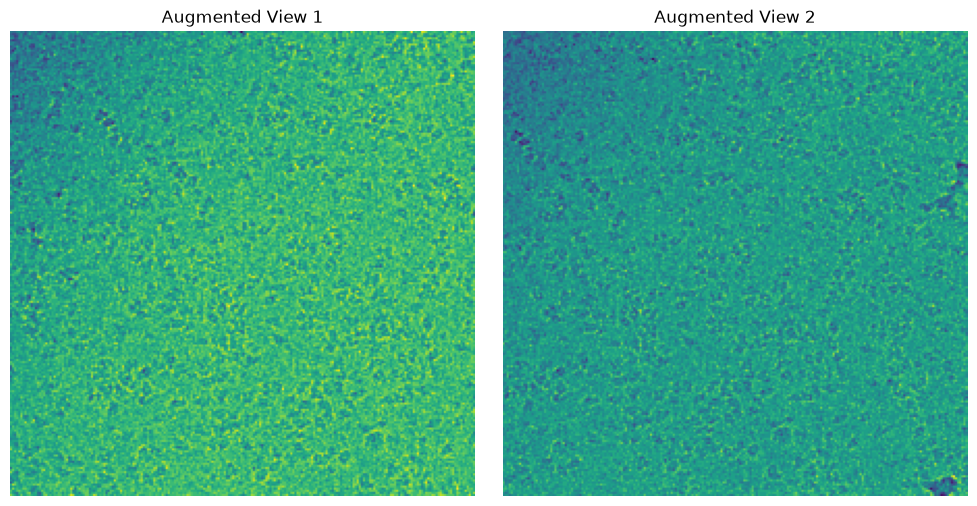

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(view1.permute(1, 2, 0))
axes[0].set_title("Augmented View 1")
axes[0].axis("off")

axes[1].imshow(view2.permute(1, 2, 0))
axes[1].set_title("Augmented View 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()